# ANALYSE DES VULNERABILITES FONCIERES DU SCOT
## Modele de Melange Gaussien (GMM) - Pipeline Complet
---

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

---
## 1. CHARGEMENT ET EXPLORATION DES DONNEES

In [2]:
chemin_gpkg_sol = 'unites_foncieres_score_estime.500+ points.gpkg'
gdf_sol = gpd.read_file(chemin_gpkg_sol)

print(f"Table Sol : {gdf_sol.shape[0]:,} lignes | {gdf_sol.shape[1]} colonnes")
print(f"Projection : {gdf_sol.crs}")
print(f"\nColonnes : {gdf_sol.columns.tolist()}")

Table Sol : 273,630 lignes | 21 colonnes
Projection : EPSG:2154

Colonnes : ['idtup', 'idcom', 'idcomtxt', 'ccodep', 'typetup', 'ssuf', 'dcntpa', 'dcntarti', 'dcntnaf', 'cgrnumd', 'cgrnumdtxt', 'jannatmin', 'jannatmax', 'jannatminh', 'jannatmaxh', 'area_geom_m2', 'x', 'y', 'score_agronomique_estime', 'variance_krigeage', 'geometry']


In [3]:
chemin_climat = 'TUP_score_agroclimatique.gpkg'
df_climat = gpd.read_file(chemin_climat)

print(f"Table Climat : {df_climat.shape[0]:,} lignes | {df_climat.shape[1]} colonnes")
print(f"\nColonnes : {df_climat.columns.tolist()}")

Table Climat : 273,630 lignes | 39 colonnes

Colonnes : ['idtup', 'idcom', 'idcomtxt', 'ccodep', 'typetup', 'ssuf', 'dcntpa', 'dcntarti', 'dcntnaf', 'cgrnumd', 'cgrnumdtxt', 'jannatmin', 'jannatmax', 'jannatminh', 'jannatmaxh', 'area_geom_m2', 'NUM_POSTE', 'NOM_USUEL', 'RR_ANN_MM', 'ETP_ANN_MM', 'ETP_MM_J', 'TM_ANN_C', 'TN_MIN_C', 'TX_MAX_C', 'S_RR', 'S_TM', 'S_TX', 'S_TN', 'S_ETP', 'S_TEMP', 'SCORE_FINAL', 'SCORE_CLASSE', 'SCORE_CLASS_NUM', 'COLOR_HEX', 'ETP_PART_ESTIMEE', 'ANNEE_SCORE', 'DIST_STATION_M', 'DIST_STATION_KM', 'geometry']


---
## 2. FUSION DES BASES (SOL + CLIMAT)

In [4]:
colonnes_climat_utiles = [
    'idtup', 'SCORE_FINAL', 'SCORE_CLASSE', 'SCORE_CLASS_NUM',
    'RR_ANN_MM', 'ETP_ANN_MM', 'TM_ANN_C', 'TX_MAX_C', 'DIST_STATION_KM'
]

df_climat_filtre = df_climat[colonnes_climat_utiles]
tup_super_base = gdf_sol.merge(df_climat_filtre, on='idtup', how='left')

print(f"Super-Base fusionnee : {tup_super_base.shape[0]:,} lignes | {tup_super_base.shape[1]} colonnes")
tup_super_base[['idtup', 'score_agronomique_estime', 'SCORE_FINAL', 'SCORE_CLASSE', 'TM_ANN_C']].head()

Super-Base fusionnee : 273,630 lignes | 29 colonnes


,idtup,score_agronomique_estime,SCORE_FINAL,SCORE_CLASSE,TM_ANN_C
0,070050000C1127,73.40,61.30,S2 - favorable,11.83
1,070050000C1129,73.40,61.30,S2 - favorable,11.83
2,070050000C1130,73.40,61.30,S2 - favorable,11.83
3,070050000C1142,73.41,61.30,S2 - favorable,11.83
4,070050000C1182,73.43,61.30,S2 - favorable,11.83


---
## 3. INTEGRATION DU RPG-PAC (IQE ET SURFACE AGRICOLE)

In [5]:
rpg_pac = gpd.read_file('RPG_IQE_SCOT_RPB.gpkg')

if rpg_pac.crs is None or rpg_pac.crs.to_epsg() != 2154:
    rpg_pac = rpg_pac.to_crs(epsg=2154)
if tup_super_base.crs is None or tup_super_base.crs.to_epsg() != 2154:
    tup_super_base = tup_super_base.to_crs(epsg=2154)

print(f"RPG-PAC : {rpg_pac.shape[0]:,} ilots")

RPG-PAC : 65,067 ilots


In [6]:
rpg_light = rpg_pac[['IQE_NORMALISE', 'geometry']].copy()

print("Intersection spatiale TUP x RPG...")
intersection = gpd.overlay(
    tup_super_base[['idtup', 'geometry']], 
    rpg_light, 
    how='intersection'
)

intersection['surf_agri_morceau'] = intersection.geometry.area / 10000
intersection['iqe_pondere'] = intersection['IQE_NORMALISE'] * intersection['surf_agri_morceau']

stats_tup = intersection.groupby('idtup').agg({
    'surf_agri_morceau': 'sum',
    'iqe_pondere': 'sum'
}).reset_index()

stats_tup['IQE_MOYEN'] = stats_tup['iqe_pondere'] / stats_tup['surf_agri_morceau']
stats_tup = stats_tup.rename(columns={'surf_agri_morceau': 'SURFACE_AGRI_TOTALE_HA'})
stats_tup = stats_tup.drop(columns=['iqe_pondere'])

tup_finale = tup_super_base.merge(stats_tup, on='idtup', how='left')
tup_finale['SURFACE_AGRI_TOTALE_HA'] = tup_finale['SURFACE_AGRI_TOTALE_HA'].fillna(0)
tup_finale['IQE_MOYEN'] = tup_finale['IQE_MOYEN'].fillna(0)
tup_finale['surface_tup_ha'] = tup_finale.geometry.area / 10000
tup_finale['POURCENTAGE_AGRICOLE'] = (tup_finale['SURFACE_AGRI_TOTALE_HA'] / tup_finale['surface_tup_ha']) * 100

print(f"Base enrichie : {tup_finale.shape[0]:,} UF")
tup_finale[['idtup', 'score_agronomique_estime', 'SCORE_FINAL', 'IQE_MOYEN', 'POURCENTAGE_AGRICOLE']].head(10)

Intersection spatiale TUP x RPG...
Base enrichie : 273,630 UF


,idtup,score_agronomique_estime,SCORE_FINAL,IQE_MOYEN,POURCENTAGE_AGRICOLE
0,070050000C1127,73.40,61.30,0.00,0.00
1,070050000C1129,73.40,61.30,0.00,0.00
2,070050000C1130,73.40,61.30,0.11,3.27
3,070050000C1142,73.41,61.30,0.12,96.91
4,070050000C1182,73.43,61.30,0.10,92.08
5,070050000C1189,73.43,61.30,0.00,0.00
6,070050000C1217,73.43,61.30,0.00,68.28
7,070050000C1320,73.43,61.30,0.00,0.00
8,070050000C1329,73.44,61.30,0.00,100.00
9,070050000C1344,73.46,61.30,0.00,0.00


---
## 4. CALCUL DE LA DISTANCE AU BATI

In [7]:
gdf_bati = gpd.read_file('Bati_SCoT_RPB (2).gpkg')

print(f"Bati : {gdf_bati.shape[0]:,} batiments")
print(f"\nRepartition des usages :")
print(gdf_bati['USAGE1'].value_counts())

Bati : 401,198 batiments

Repartition des usages :
USAGE1
Indifférencié             221072
Résidentiel               132488
Annexe                     24139
Commercial et services     11462
Agricole                    6782
Industriel                  4163
Religieux                    738
Sportif                      354
Name: count, dtype: int64


In [8]:
bati_urbain = gdf_bati[
    ~gdf_bati['USAGE1'].astype(str).str.contains('Agricole|agricole', na=False, case=False)
].copy()

print(f"Batiments urbains retenus : {bati_urbain.shape[0]:,}")

if tup_finale.crs.to_epsg() != 2154:
    tup_finale = tup_finale.to_crs(epsg=2154)

print("Calcul des distances (sjoin_nearest)...")
tup_centroides = tup_finale.copy()
tup_centroides['geometry'] = tup_finale.geometry.centroid

bati_light = bati_urbain[['geometry']].copy()
bati_light['geometry'] = bati_light.geometry.centroid

jointure = gpd.sjoin_nearest(
    tup_centroides[['idtup', 'geometry']],
    bati_light,
    how='left',
    distance_col='DIST_BATI_M'
)

jointure = jointure.drop_duplicates(subset=['idtup'])
jointure['DIST_BATI_KM'] = (jointure['DIST_BATI_M'] / 1000).round(3)

tup_avec_distance = tup_finale.merge(
    jointure[['idtup', 'DIST_BATI_KM']],
    on='idtup',
    how='left'
)
tup_avec_distance['DIST_BATI_KM'] = tup_avec_distance['DIST_BATI_KM'].fillna(0)

print(f"\nBase finale prete pour le ML : {tup_avec_distance.shape[0]:,} UF")
colonnes_finales = ['idtup', 'score_agronomique_estime', 'SCORE_FINAL', 'IQE_MOYEN', 'POURCENTAGE_AGRICOLE', 'DIST_BATI_KM']
tup_avec_distance[colonnes_finales].head(10)

Batiments urbains retenus : 394,416
Calcul des distances (sjoin_nearest)...

Base finale prete pour le ML : 273,630 UF


,idtup,score_agronomique_estime,SCORE_FINAL,IQE_MOYEN,POURCENTAGE_AGRICOLE,DIST_BATI_KM
0,070050000C1127,73.40,61.30,0.00,0.00,0.06
1,070050000C1129,73.40,61.30,0.00,0.00,0.02
2,070050000C1130,73.40,61.30,0.11,3.27,0.01
3,070050000C1142,73.41,61.30,0.12,96.91,0.17
4,070050000C1182,73.43,61.30,0.10,92.08,0.06
5,070050000C1189,73.43,61.30,0.00,0.00,0.05
6,070050000C1217,73.43,61.30,0.00,68.28,0.11
7,070050000C1320,73.43,61.30,0.00,0.00,0.12
8,070050000C1329,73.44,61.30,0.00,100.00,0.14
9,070050000C1344,73.46,61.30,0.00,0.00,0.04


---
## 5. NORMALISATION DES VARIABLES

In [9]:
scaler = MinMaxScaler()

colonnes_a_normaliser = [
    'score_agronomique_estime', 'SCORE_FINAL', 'IQE_MOYEN', 
    'POURCENTAGE_AGRICOLE', 'DIST_BATI_KM'
]

tup_ml = tup_avec_distance.copy()

for col in colonnes_a_normaliser:
    nom_col_norm = col + '_NORM'
    tup_ml[nom_col_norm] = scaler.fit_transform(tup_ml[[col]])

colonnes_ml = ['idtup'] + [col + '_NORM' for col in colonnes_a_normaliser]
tup_ml_final = tup_ml[colonnes_ml].copy()

print("Matrice normalisee [0-1] :")
tup_ml_final.head(10)

Matrice normalisee [0-1] :


,idtup,score_agronomique_estime_NORM,SCORE_FINAL_NORM,IQE_MOYEN_NORM,POURCENTAGE_AGRICOLE_NORM,DIST_BATI_KM_NORM
0,070050000C1127,0.12,0.85,0.00,0.00,0.02
1,070050000C1129,0.12,0.85,0.00,0.00,0.01
2,070050000C1130,0.12,0.85,0.11,0.02,0.01
3,070050000C1142,0.12,0.85,0.12,0.46,0.07
4,070050000C1182,0.12,0.85,0.10,0.43,0.03
5,070050000C1189,0.12,0.85,0.00,0.00,0.02
6,070050000C1217,0.12,0.85,0.00,0.32,0.05
7,070050000C1320,0.12,0.85,0.00,0.00,0.05
8,070050000C1329,0.13,0.85,0.00,0.47,0.06
9,070050000C1344,0.13,0.85,0.00,0.00,0.02


---
## 6. SELECTION DU NOMBRE OPTIMAL DE CLUSTERS (BIC)

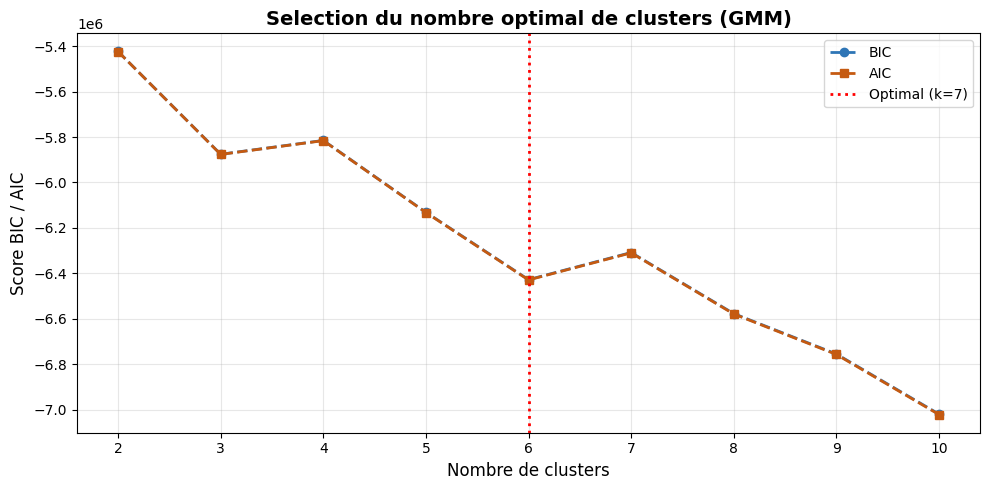


Nombre optimal de clusters : 6 (minimum BIC)


In [10]:
colonnes_algo = [
    'score_agronomique_estime_NORM', 'SCORE_FINAL_NORM', 
    'IQE_MOYEN_NORM', 'POURCENTAGE_AGRICOLE_NORM', 'DIST_BATI_KM_NORM'
]
X = tup_ml_final[colonnes_algo]

n_composantes = range(2, 11)
valeurs_bic = []
valeurs_aic = []

for n in n_composantes:
    gmm_test = GaussianMixture(n_components=n, covariance_type='full', random_state=42, n_init=3)
    gmm_test.fit(X)
    valeurs_bic.append(gmm_test.bic(X))
    valeurs_aic.append(gmm_test.aic(X))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_composantes, valeurs_bic, marker='o', linestyle='--', color='#2E75B6', linewidth=2, label='BIC')
ax.plot(n_composantes, valeurs_aic, marker='s', linestyle='--', color='#C55A11', linewidth=2, label='AIC')
ax.axvline(x=6, color='red', linestyle=':', linewidth=2, label='Optimal (k=7)')
ax.set_xlabel('Nombre de clusters', fontsize=12)
ax.set_ylabel('Score BIC / AIC', fontsize=12)
ax.set_title('Selection du nombre optimal de clusters (GMM)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graphique_bic_aic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNombre optimal de clusters : 6 (minimum BIC)")

---
## 7. MODELE GMM FINAL (7 GROUPES)

In [25]:
NOMBRE_OPTIMAL = 6

gmm_final = GaussianMixture(
    n_components=NOMBRE_OPTIMAL, 
    covariance_type='full', 
    random_state=42,
    n_init=5
)
gmm_final.fit(X)

tup_ml_final['GROUPE_GMM'] = gmm_final.predict(X)

print(f"Modele GMM entraine avec {NOMBRE_OPTIMAL} clusters")
print(f"Log-vraisemblance : {gmm_final.score(X):.4f}")
print(f"Convergence : {gmm_final.converged_}")
print(f"Iterations : {gmm_final.n_iter_}")

Modele GMM entraine avec 6 clusters
Log-vraisemblance : 11.7486
Convergence : True
Iterations : 16


---
## 8. ANALYSE DES PROFILS PAR GROUPE

In [26]:
tup_analyse = tup_avec_distance.copy()
tup_analyse['GROUPE_GMM'] = tup_ml_final['GROUPE_GMM'].values

profils = tup_analyse.groupby('GROUPE_GMM').agg({
    'DIST_BATI_KM': 'mean',
    'POURCENTAGE_AGRICOLE': 'mean',
    'IQE_MOYEN': 'mean',
    'score_agronomique_estime': 'mean',
    'SCORE_FINAL': 'mean',
    'idtup': 'count'
}).rename(columns={'idtup': 'NB_UF'}).round(2)

profils = profils.sort_values(by='DIST_BATI_KM')

print("PROFILS MOYENS PAR GROUPE (tries par distance au bati) :")
print("="*80)
profils

PROFILS MOYENS PAR GROUPE (tries par distance au bati) :


,DIST_BATI_KM,POURCENTAGE_AGRICOLE,IQE_MOYEN,score_agronomique_estime,SCORE_FINAL,NB_UF
GROUPE_GMM,,,,,,
5,0.08,0.01,0.00,74.31,46.60,62261
1,0.09,0.01,0.00,73.67,60.50,53781
0,0.13,2.32,0.07,74.89,45.72,12907
3,0.17,67.55,0.05,74.57,48.48,57058
4,0.17,0.01,0.00,75.38,45.32,65524
2,0.39,34.39,0.00,76.62,28.88,22099


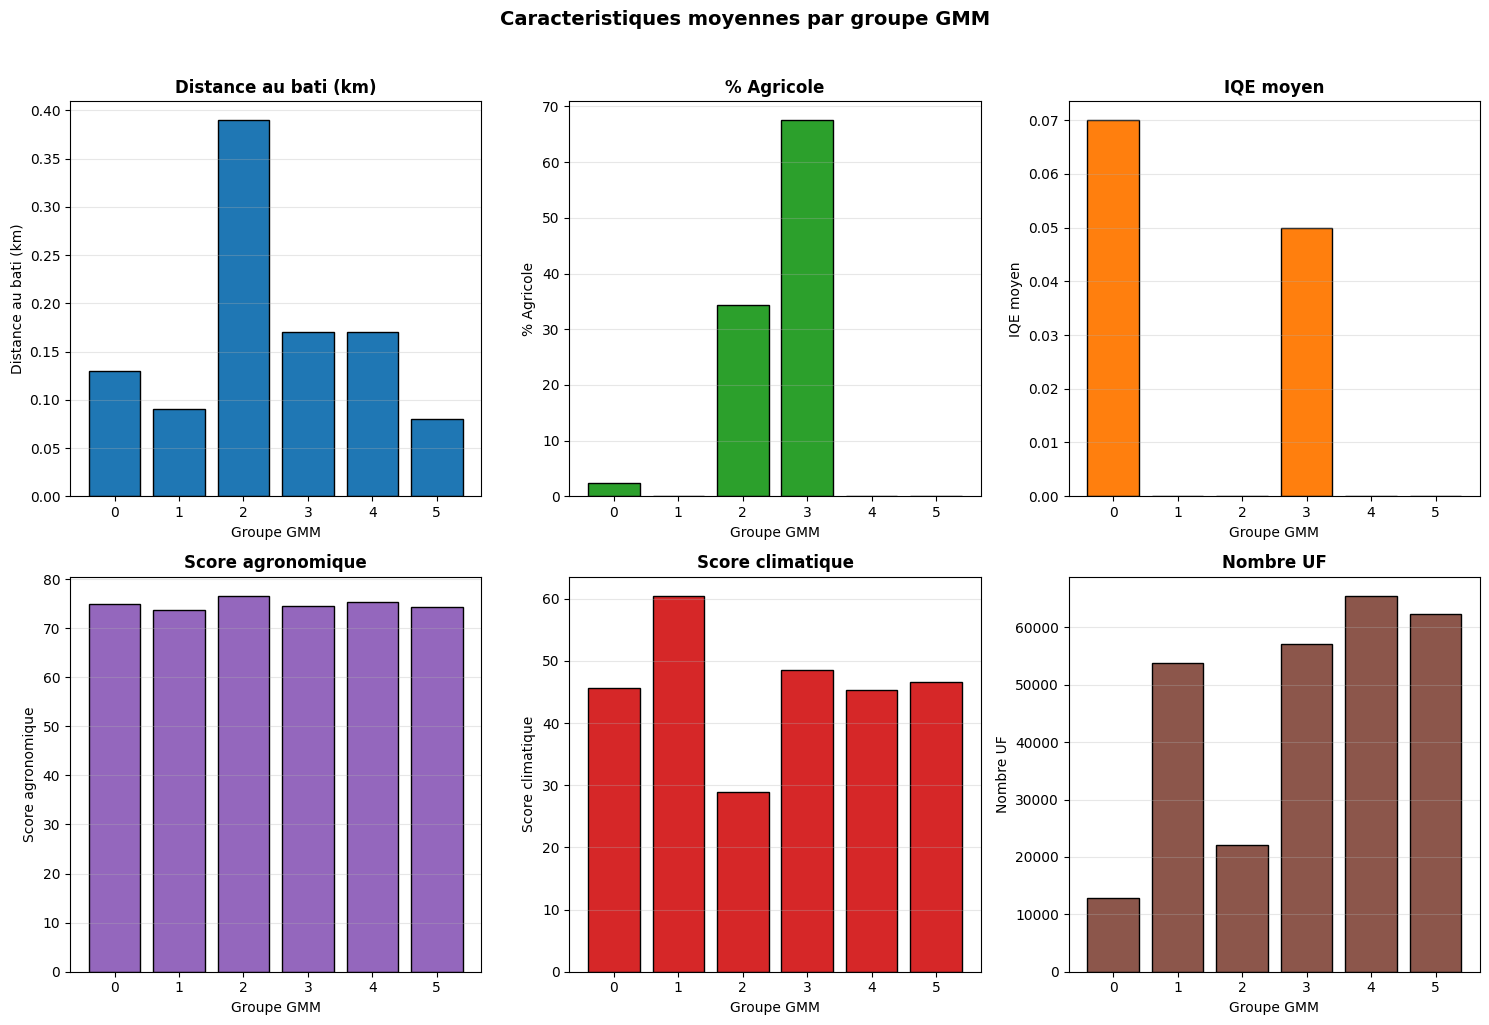

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

variables = ['DIST_BATI_KM', 'POURCENTAGE_AGRICOLE', 'IQE_MOYEN', 
             'score_agronomique_estime', 'SCORE_FINAL', 'NB_UF']
titres = ['Distance au bati (km)', '% Agricole', 'IQE moyen', 
          'Score agronomique', 'Score climatique', 'Nombre UF']
couleurs = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#d62728', '#8c564b']

for i, (var, titre, couleur) in enumerate(zip(variables, titres, couleurs)):
    ax = axes[i//3, i%3]
    profils_sorted = profils.sort_index()
    ax.bar(profils_sorted.index.astype(str), profils_sorted[var], color=couleur, edgecolor='black')
    ax.set_xlabel('Groupe GMM')
    ax.set_ylabel(titre)
    ax.set_title(titre, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Caracteristiques moyennes par groupe GMM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('profils_par_groupe.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. CALCUL DES PROBABILITES D'ARTIFICIALISATION

In [28]:
probas_7 = gmm_final.predict_proba(X)

GROUPES_URBAINS = [2, 4]
tup_ml_final['PROBA_ARTIFICIALISATION_POURCENT'] = (
    probas_7[:, GROUPES_URBAINS].sum(axis=1) * 100
).round(2)

print("STATISTIQUES PROBABILITE ARTIFICIALISATION :")
print("="*50)
print(tup_ml_final['PROBA_ARTIFICIALISATION_POURCENT'].describe().round(2))

STATISTIQUES PROBABILITE ARTIFICIALISATION :
count   273630.00
mean        32.00
std         46.48
min          0.00
25%          0.00
50%          0.00
75%         99.99
max        100.00
Name: PROBA_ARTIFICIALISATION_POURCENT, dtype: float64


In [29]:
p = tup_ml_final['PROBA_ARTIFICIALISATION_POURCENT']
total = len(p)

uf_urbain = (p >= 75).sum()
uf_transition = ((p > 10) & (p < 75)).sum()
uf_rural = (p <= 10).sum()

print("REPARTITION DES UNITES FONCIERES :")
print("="*60)
print(f"Profil URBAIN dominant  (P >= 75%) : {uf_urbain:>8,} UF ({uf_urbain/total*100:.1f}%)")
print(f"Zone de TRANSITION      (10% < P < 75%) : {uf_transition:>8,} UF ({uf_transition/total*100:.1f}%)")
print(f"Profil RURAL/NATUREL    (P <= 10%) : {uf_rural:>8,} UF ({uf_rural/total*100:.1f}%)")
print(f"{'='*60}")
print(f"TOTAL : {total:,} UF")

REPARTITION DES UNITES FONCIERES :
Profil URBAIN dominant  (P >= 75%) :   87,206 UF (31.9%)
Zone de TRANSITION      (10% < P < 75%) :    1,279 UF (0.5%)
Profil RURAL/NATUREL    (P <= 10%) :  185,145 UF (67.7%)
TOTAL : 273,630 UF


---
## 10. ATTRIBUTION DES NOMS DE GROUPES

In [30]:
tup_ultime = tup_avec_distance.merge(
    tup_ml_final[['idtup', 'GROUPE_GMM', 'PROBA_ARTIFICIALISATION_POURCENT']],
    on='idtup',
    how='left'
)

conditions_groupes = [
    (tup_ultime['GROUPE_GMM'] == 2),
    (tup_ultime['GROUPE_GMM'] == 4),
    (tup_ultime['GROUPE_GMM'] == 6),
    (tup_ultime['GROUPE_GMM'] == 5),
    (tup_ultime['GROUPE_GMM'] == 1),
    (tup_ultime['GROUPE_GMM'] == 3),
    (tup_ultime['GROUPE_GMM'] == 0)
]

noms_groupes = [
    '2 - URBAIN : Coeur urbain en surchauffe',
    '4 - URBAIN : Tissu residentiel et commercial standard',
    '6 - TRANSITION : Micro-parcellaire de lisiere (Jardins)',
    '5 - NATURE : Espaces naturels et forestiers',
    '1 - AGRICOLE : Friches potentielles (Vulnerabilite TRES FORTE)',
    '3 - AGRICOLE : Ceinture agricole sous pression (Vulnerabilite FORTE)',
    '0 - AGRICOLE : Sanctuaire Agricole Premium (A PROTEGER)'
]

tup_ultime['NOM_GROUPE_GMM'] = np.select(conditions_groupes, noms_groupes, default='Non classe')

print("REPARTITION PAR TYPOLOGIE :")
print("="*70)
print(tup_ultime['NOM_GROUPE_GMM'].value_counts().sort_index())

REPARTITION PAR TYPOLOGIE :
NOM_GROUPE_GMM
0 - AGRICOLE : Sanctuaire Agricole Premium (A PROTEGER)                 12907
1 - AGRICOLE : Friches potentielles (Vulnerabilite TRES FORTE)          53781
2 - URBAIN : Coeur urbain en surchauffe                                 22099
3 - AGRICOLE : Ceinture agricole sous pression (Vulnerabilite FORTE)    57058
4 - URBAIN : Tissu residentiel et commercial standard                   65524
5 - NATURE : Espaces naturels et forestiers                             62261
Name: count, dtype: int64


---
## 11. METRIQUES CLES POUR LA PRESENTATION

In [31]:
tup_ultime['surf_agri_ha'] = tup_ultime['surface_tup_ha'] * tup_ultime['POURCENTAGE_AGRICOLE'] / 100

terres_menacees = tup_ultime[
    (tup_ultime['PROBA_ARTIFICIALISATION_POURCENT'] >= 75) &
    (tup_ultime['POURCENTAGE_AGRICOLE'] > 0)
]

surface_totale = tup_ultime['surface_tup_ha'].sum()
surface_agri_totale = tup_ultime['surf_agri_ha'].sum()
surface_agri_menacee = terres_menacees['surf_agri_ha'].sum()

print("")
print("="*70)
print("            METRIQUES CLES - SYNTHESE TERRITORIALE")
print("="*70)
print(f"")
print(f"  Nombre total d'unites foncieres     : {len(tup_ultime):>12,}")
print(f"  Surface totale du territoire        : {surface_totale:>12,.0f} ha")
print(f"  Surface agricole declaree (PAC)     : {surface_agri_totale:>12,.0f} ha")
print(f"")
print("-"*70)
print(f"  PRESSION URBAINE")
print("-"*70)
print(f"  UF a profil urbain (P >= 75%)       : {uf_urbain:>12,} ({uf_urbain/total*100:.1f}%)")
print(f"  UF en zone de transition            : {uf_transition:>12,} ({uf_transition/total*100:.1f}%)")
print(f"  UF a profil rural/naturel           : {uf_rural:>12,} ({uf_rural/total*100:.1f}%)")
print(f"")
print("-"*70)
print(f"  VULNERABILITE AGRICOLE")
print("-"*70)
print(f"  UF agricoles sous pression urbaine  : {len(terres_menacees):>12,}")
print(f"  Surface agricole menacee            : {surface_agri_menacee:>12,.0f} ha")
print(f"  Part du foncier agricole menace     : {surface_agri_menacee/surface_agri_totale*100:>12.2f} %")
print(f"")
print("="*70)


            METRIQUES CLES - SYNTHESE TERRITORIALE

  Nombre total d'unites foncieres     :      273,630
  Surface totale du territoire        :      306,190 ha
  Surface agricole declaree (PAC)     :       97,210 ha

----------------------------------------------------------------------
  PRESSION URBAINE
----------------------------------------------------------------------
  UF a profil urbain (P >= 75%)       :       87,206 (31.9%)
  UF en zone de transition            :        1,279 (0.5%)
  UF a profil rural/naturel           :      185,145 (67.7%)

----------------------------------------------------------------------
  VULNERABILITE AGRICOLE
----------------------------------------------------------------------
  UF agricoles sous pression urbaine  :       13,453
  Surface agricole menacee            :       14,017 ha
  Part du foncier agricole menace     :        14.42 %



In [32]:
metriques_groupes = tup_ultime.groupby('NOM_GROUPE_GMM').agg({
    'idtup': 'count',
    'surface_tup_ha': 'sum',
    'surf_agri_ha': 'sum',
    'DIST_BATI_KM': 'mean',
    'POURCENTAGE_AGRICOLE': 'mean',
    'score_agronomique_estime': 'mean',
    'SCORE_FINAL': 'mean',
    'PROBA_ARTIFICIALISATION_POURCENT': 'mean'
}).rename(columns={
    'idtup': 'NB_UF',
    'surface_tup_ha': 'SURFACE_HA',
    'surf_agri_ha': 'SURF_AGRI_HA',
    'DIST_BATI_KM': 'DIST_MOY_KM',
    'POURCENTAGE_AGRICOLE': 'PCT_AGRI',
    'score_agronomique_estime': 'SCORE_SOL',
    'SCORE_FINAL': 'SCORE_CLIMAT',
    'PROBA_ARTIFICIALISATION_POURCENT': 'PROBA_ARTIF'
}).round(2)

metriques_groupes = metriques_groupes.sort_values('DIST_MOY_KM')

print("METRIQUES DETAILLEES PAR GROUPE :")
print("="*100)
metriques_groupes

METRIQUES DETAILLEES PAR GROUPE :


,NB_UF,SURFACE_HA,SURF_AGRI_HA,DIST_MOY_KM,PCT_AGRI,SCORE_SOL,SCORE_CLIMAT,PROBA_ARTIF
NOM_GROUPE_GMM,,,,,,,,
5 - NATURE : Espaces naturels et forestiers,62261,35077.79,6.97,0.08,0.01,74.31,46.60,0.05
1 - AGRICOLE : Friches potentielles (Vulnerabilite TRES FORTE),53781,30249.54,7.63,0.09,0.01,73.67,60.50,0.00
0 - AGRICOLE : Sanctuaire Agricole Premium (A PROTEGER),12907,19293.62,391.97,0.13,2.32,74.89,45.72,0.35
3 - AGRICOLE : Ceinture agricole sous pression (Vulnerabilite FORTE),57058,129730.76,82060.19,0.17,67.55,74.57,48.48,0.32
4 - URBAIN : Tissu residentiel et commercial standard,65524,54111.93,15.83,0.17,0.01,75.38,45.32,99.96
2 - URBAIN : Coeur urbain en surchauffe,22099,37726.29,14727.50,0.39,34.39,76.62,28.88,98.71


---
## 12. VISUALISATIONS POUR LA PRESENTATION

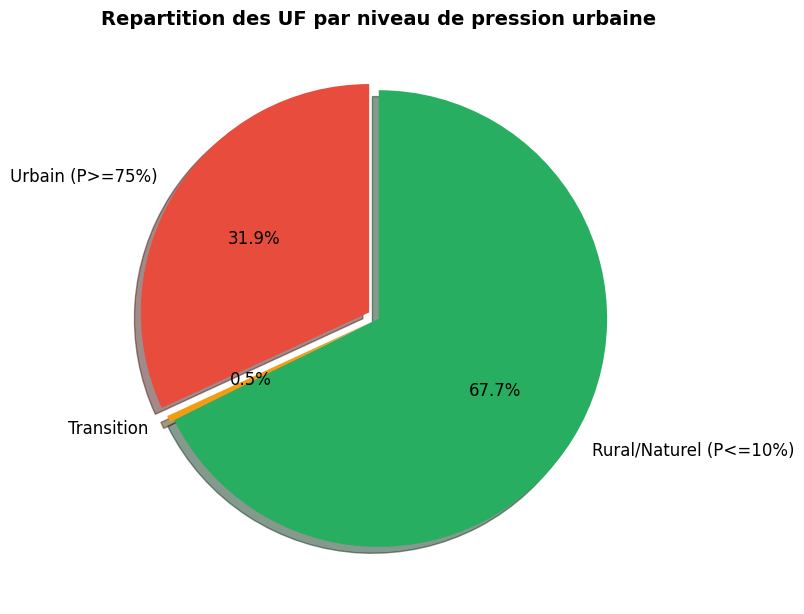

In [33]:
labels = ['Urbain (P>=75%)', 'Transition', 'Rural/Naturel (P<=10%)']
sizes = [uf_urbain, uf_transition, uf_rural]
colors = ['#E74C3C', '#F39C12', '#27AE60']
explode = (0.05, 0.02, 0)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors,
    autopct='%1.1f%%', 
    shadow=True, 
    startangle=90,
    textprops={'fontsize': 12}
)
ax.set_title('Repartition des UF par niveau de pression urbaine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('repartition_pression_urbaine.png', dpi=150, bbox_inches='tight')
plt.show()

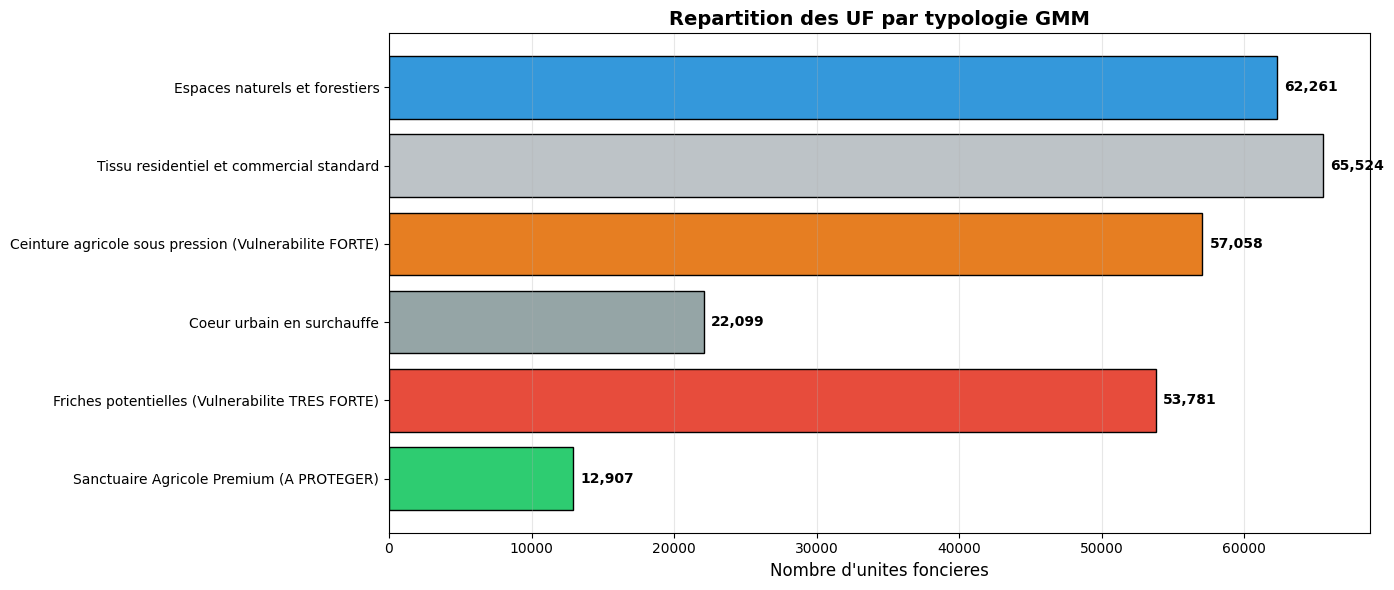

In [34]:
groupes_count = tup_ultime['NOM_GROUPE_GMM'].value_counts().sort_index()

colors_groupes = {
    '0 - AGRICOLE : Sanctuaire Agricole Premium (A PROTEGER)': '#2ECC71',
    '1 - AGRICOLE : Friches potentielles (Vulnerabilite TRES FORTE)': '#E74C3C',
    '2 - URBAIN : Coeur urbain en surchauffe': '#95A5A6',
    '3 - AGRICOLE : Ceinture agricole sous pression (Vulnerabilite FORTE)': '#E67E22',
    '4 - URBAIN : Tissu residentiel et commercial standard': '#BDC3C7',
    '5 - NATURE : Espaces naturels et forestiers': '#3498DB',
    '6 - TRANSITION : Micro-parcellaire de lisiere (Jardins)': '#F1C40F'
}

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    range(len(groupes_count)), 
    groupes_count.values,
    color=[colors_groupes.get(g, '#7F8C8D') for g in groupes_count.index],
    edgecolor='black'
)
ax.set_yticks(range(len(groupes_count)))
ax.set_yticklabels([g.split(' : ')[1] if ' : ' in g else g for g in groupes_count.index], fontsize=10)
ax.set_xlabel('Nombre d\'unites foncieres', fontsize=12)
ax.set_title('Repartition des UF par typologie GMM', fontsize=14, fontweight='bold')

for bar, val in zip(bars, groupes_count.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2, f'{val:,}', 
            va='center', fontsize=10, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('repartition_par_typologie.png', dpi=150, bbox_inches='tight')
plt.show()

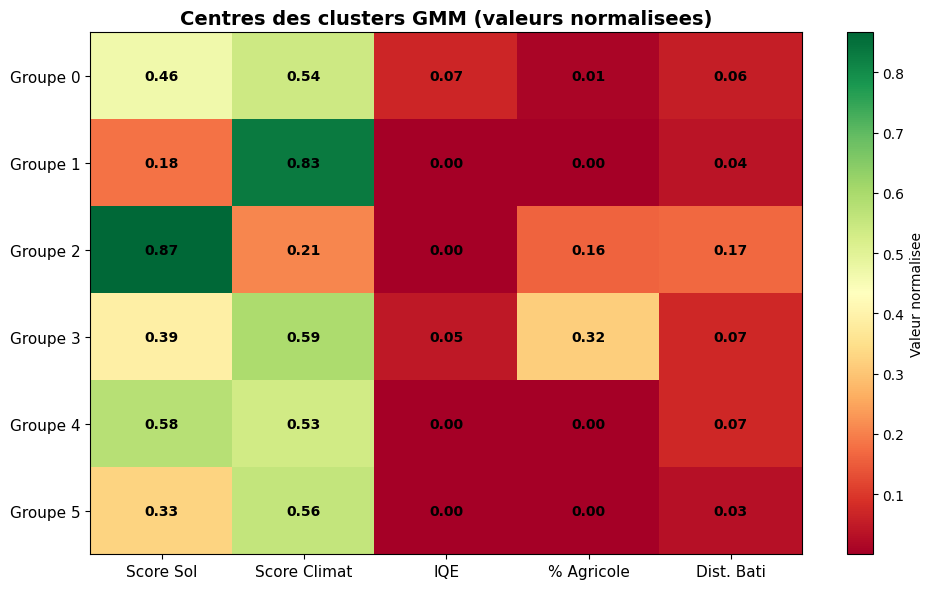

In [36]:
centres_gmm = pd.DataFrame(
    gmm_final.means_,
    columns=['Score Sol', 'Score Climat', 'IQE', '% Agricole', 'Dist. Bati']
)
centres_gmm.index = [f'Groupe {i}' for i in range(6)]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(centres_gmm.values, cmap='RdYlGn', aspect='auto')

ax.set_xticks(range(len(centres_gmm.columns)))
ax.set_xticklabels(centres_gmm.columns, fontsize=11)
ax.set_yticks(range(len(centres_gmm.index)))
ax.set_yticklabels(centres_gmm.index, fontsize=11)

for i in range(len(centres_gmm.index)):
    for j in range(len(centres_gmm.columns)):
        val = centres_gmm.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_title('Centres des clusters GMM (valeurs normalisees)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Valeur normalisee')
plt.tight_layout()
plt.savefig('centres_clusters_gmm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. CARTE INTERACTIVE FOLIUM

In [37]:
tup_carte = tup_ultime.copy()
tup_carte = tup_carte.to_crs(epsg=4326)

echantillon = tup_carte.sample(n=min(5000, len(tup_carte)), random_state=42)

centroid_global = echantillon.geometry.centroid.unary_union.centroid
m = folium.Map(
    location=[centroid_global.y, centroid_global.x],
    zoom_start=10,
    tiles='cartodbpositron'
)

couleurs_folium = {
    0: '#2ECC71',
    1: '#E74C3C',
    2: '#95A5A6',
    3: '#E67E22',
    4: '#BDC3C7',
    5: '#3498DB',
    6: '#F1C40F'
}

for idx, row in echantillon.iterrows():
    centroid = row.geometry.centroid
    groupe = int(row['GROUPE_GMM']) if pd.notna(row['GROUPE_GMM']) else -1
    couleur = couleurs_folium.get(groupe, '#7F8C8D')
    
    popup_text = f"""
    <b>ID:</b> {row['idtup']}<br>
    <b>Groupe:</b> {row['NOM_GROUPE_GMM']}<br>
    <b>Proba Artif:</b> {row['PROBA_ARTIFICIALISATION_POURCENT']:.1f}%<br>
    <b>% Agricole:</b> {row['POURCENTAGE_AGRICOLE']:.1f}%<br>
    <b>Dist Bati:</b> {row['DIST_BATI_KM']:.3f} km
    """
    
    folium.CircleMarker(
        location=[centroid.y, centroid.x],
        radius=4,
        color=couleur,
        fill=True,
        fillColor=couleur,
        fillOpacity=0.7,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(m)

legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; background-color: white; 
            padding: 10px; border: 2px solid grey; border-radius: 5px; font-size: 12px;">
    <b>Typologie GMM</b><br>
    <i style="background:#2ECC71; width:12px; height:12px; display:inline-block;"></i> Sanctuaire Agricole<br>
    <i style="background:#E74C3C; width:12px; height:12px; display:inline-block;"></i> Friches potentielles<br>
    <i style="background:#E67E22; width:12px; height:12px; display:inline-block;"></i> Ceinture sous pression<br>
    <i style="background:#3498DB; width:12px; height:12px; display:inline-block;"></i> Espaces naturels<br>
    <i style="background:#F1C40F; width:12px; height:12px; display:inline-block;"></i> Lisiere/Jardins<br>
    <i style="background:#95A5A6; width:12px; height:12px; display:inline-block;"></i> Coeur urbain<br>
    <i style="background:#BDC3C7; width:12px; height:12px; display:inline-block;"></i> Tissu residentiel<br>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m.save('carte_typologie_gmm.html')
print("Carte sauvegardee : carte_typologie_gmm.html")
m

Carte sauvegardee : carte_typologie_gmm.html


---
## 14. EXPORT FINAL (GEOPACKAGE POUR QGIS)

In [38]:
colonnes_export = [
    'idtup', 'idcom', 'idcomtxt', 'ccodep',
    'score_agronomique_estime', 'variance_krigeage',
    'SCORE_FINAL', 'SCORE_CLASSE', 'TM_ANN_C', 'RR_ANN_MM',
    'IQE_MOYEN', 'POURCENTAGE_AGRICOLE', 'SURFACE_AGRI_TOTALE_HA',
    'DIST_BATI_KM',
    'GROUPE_GMM', 'NOM_GROUPE_GMM', 'PROBA_ARTIFICIALISATION_POURCENT',
    'surface_tup_ha', 'geometry'
]

tup_export = tup_ultime[[c for c in colonnes_export if c in tup_ultime.columns]].copy()
tup_export = tup_export.to_crs(epsg=2154)

nom_fichier = "SCOT_TYPOLOGIE_GMM_7GROUPES.gpkg"
tup_export.to_file(nom_fichier, driver="GPKG")

print(f"Export termine : {nom_fichier}")
print(f"Nombre d'entites : {len(tup_export):,}")
print(f"Colonnes exportees : {len(tup_export.columns)}")

Export termine : SCOT_TYPOLOGIE_GMM_7GROUPES.gpkg
Nombre d'entites : 273,630
Colonnes exportees : 19


---
## 15. SYNTHESE FINALE

In [40]:
print("")
print("="*80)
print("                    SYNTHESE - ANALYSE TYPOLOGIQUE GMM")
print("="*80)
print("")
print("METHODOLOGIE")
print("-"*80)
print("  Algorithme      : Gaussian Mixture Model (GMM)")
print("  Nombre clusters : 6 (optimise par critere BIC)")
print("  Variables       : Score sol, Score climat, IQE, % agricole, Distance bati")
print("  Normalisation   : Min-Max [0-1]")
print("")
print("RESULTATS CLES")
print("-"*80)
print(f"  Total UF analysees              : {len(tup_ultime):>10,}")
print(f"  Surface totale                  : {surface_totale:>10,.0f} ha")
print(f"  Surface agricole (PAC)          : {surface_agri_totale:>10,.0f} ha")
print("")
print("TYPOLOGIE IDENTIFIEE")
print("-"*80)
for nom, count in groupes_count.items():
    pct = count / len(tup_ultime) * 100
    print(f"  {nom.split(' : ')[1] if ' : ' in nom else nom[:40]:<45} : {count:>7,} ({pct:>5.1f}%)")
print("")
print("FICHIERS GENERES")
print("-"*80)
print("  - graphique_bic_aic.png")
print("  - profils_par_groupe.png")
print("  - repartition_pression_urbaine.png")
print("  - repartition_par_typologie.png")
print("  - centres_clusters_gmm.png")
print("  - carte_typologie_gmm.html")
print("  - SCOT_TYPOLOGIE_GMM_7GROUPES.gpkg")
print("")
print("="*80)


                    SYNTHESE - ANALYSE TYPOLOGIQUE GMM

METHODOLOGIE
--------------------------------------------------------------------------------
  Algorithme      : Gaussian Mixture Model (GMM)
  Nombre clusters : 6 (optimise par critere BIC)
  Variables       : Score sol, Score climat, IQE, % agricole, Distance bati
  Normalisation   : Min-Max [0-1]

RESULTATS CLES
--------------------------------------------------------------------------------
  Total UF analysees              :    273,630
  Surface totale                  :    306,190 ha
  Surface agricole (PAC)          :     97,210 ha

TYPOLOGIE IDENTIFIEE
--------------------------------------------------------------------------------
  Sanctuaire Agricole Premium (A PROTEGER)      :  12,907 (  4.7%)
  Friches potentielles (Vulnerabilite TRES FORTE) :  53,781 ( 19.7%)
  Coeur urbain en surchauffe                    :  22,099 (  8.1%)
  Ceinture agricole sous pression (Vulnerabilite FORTE) :  57,058 ( 20.9%)
  Tissu resident